# Experiment 3: Measures of Central Tendency and Variability
**Aim:** Compute summary statistics (mean, median, min, max, std) for numeric variables grouped by a categorical variable. Also display basic statistical details for each species in the Iris dataset.

### Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Step 2: Load the Dataset
We use the **Iris dataset** — a classic open-source dataset available on Kaggle and UCI ML Repository.
- **URL**: https://www.kaggle.com/datasets/uciml/iris
- It contains 150 records of iris flowers with 4 numeric features (sepal/petal measurements) and 1 categorical column (species).

In [2]:
df = pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Class Label
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### Step 3: Overall Summary Statistics
Here we compute **mean, median, min, max, and standard deviation** for all numeric columns across the entire dataset.

In [3]:
# Select only the numeric measurement columns
numeric_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

# Create a single table with all statistics
overall_stats = pd.DataFrame({
    'Mean':   df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Min':    df[numeric_cols].min(),
    'Max':    df[numeric_cols].max(),
    'Std Dev':df[numeric_cols].std()
})

print('Overall Statistics (all species):')
display(overall_stats)

Overall Statistics (all species):


,Mean,Median,Min,Max,Std Dev
SepalLengthCm,5.843333,5.80,4.3,7.9,0.828066
SepalWidthCm,3.054000,3.00,2.0,4.4,0.433594
PetalLengthCm,3.758667,4.35,1.0,6.9,1.764420
PetalWidthCm,1.198667,1.30,0.1,2.5,0.763161


### Step 4: Summary Statistics Grouped by Species (Categorical Variable)
We group the numeric variables by `Class Label` (the categorical variable = species name) and compute summary statistics for each group.

In [4]:
# Group by 'Class Label' and compute summary statistics
grouped_stats = df.groupby('Class Label')[numeric_cols].agg(['mean', 'median', 'min', 'max', 'std'])

print('Statistics Grouped by Species:')
display(grouped_stats)

Statistics Grouped by Species:


SepalLengthCm                            SepalWidthCm         \
                         mean median  min  max       std         mean median   
Class Label                                                                    
Iris-setosa             5.006    5.0  4.3  5.8  0.352490        3.418    3.4   
Iris-versicolor         5.936    5.9  4.9  7.0  0.516171        2.770    2.8   
Iris-virginica          6.588    6.5  4.9  7.9  0.635880        2.974    3.0   

                                    PetalLengthCm                             \
                 min  max       std          mean median  min  max       std   
Class Label                                                                    
Iris-setosa      2.3  4.4  0.381024         1.464   1.50  1.0  1.9  0.173511   
Iris-versicolor  2.0  3.4  0.313798         4.260   4.35  3.0  5.1  0.469911   
Iris-virginica   2.2  3.8  0.322497         5.552   5.55  4.5  6.9  0.551895   

                PetalWidthCm                             
                        mean median  min  max       std  
Class Label                                              
Iris-setosa            0.244    0.2  0.1  0.6  0.107210  
Iris-versicolor        1.326    1.3  1.0  1.8  0.197753  
Iris-virginica         2.026    2.0  1.4  2.5  0.274650

### Step 5: Numeric List for Each Categorical Response
We map each unique category in `Class Label` to a numeric value and store the result as a list — one value per row.

In [5]:
# Map each category to a number: 0, 1, 2
categories = df['Class Label'].unique()
category_map = {name: idx for idx, name in enumerate(categories)}

print('Category Mapping:', category_map)

# Create the numeric list
numeric_list = [category_map[val] for val in df['Class Label']]

print('First 15 values:', numeric_list[:15])
print('Total length:', len(numeric_list))

Category Mapping: {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
First 15 values: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Total length: 150


### Step 6: Per-Species Statistical Details (Percentile, Mean, Std)
For each species — Iris-setosa, Iris-versicolor, and Iris-virginica — we display:
- Mean
- Standard Deviation
- Percentiles (25th, 50th, 75th)

We use pandas `describe()` which gives all of these at once.

In [6]:
for species in df['Class Label'].unique():
    print('=' * 45)
    print(f'Species: {species}')
    print('=' * 45)
    subset = df[df['Class Label'] == species][numeric_cols]
    display(subset.describe())
    print()

Species: Iris-setosa


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,50.00000,50.000000,50.000000,50.00000
mean,5.00600,3.418000,1.464000,0.24400
std,0.35249,0.381024,0.173511,0.10721
min,4.30000,2.300000,1.000000,0.10000
25%,4.80000,3.125000,1.400000,0.20000
50%,5.00000,3.400000,1.500000,0.20000
75%,5.20000,3.675000,1.575000,0.30000
max,5.80000,4.400000,1.900000,0.60000



Species: Iris-versicolor


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,50.000000,50.000000,50.000000,50.000000
mean,5.936000,2.770000,4.260000,1.326000
std,0.516171,0.313798,0.469911,0.197753
min,4.900000,2.000000,3.000000,1.000000
25%,5.600000,2.525000,4.000000,1.200000
50%,5.900000,2.800000,4.350000,1.300000
75%,6.300000,3.000000,4.600000,1.500000
max,7.000000,3.400000,5.100000,1.800000



Species: Iris-virginica


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,50.00000,50.000000,50.000000,50.00000
mean,6.58800,2.974000,5.552000,2.02600
std,0.63588,0.322497,0.551895,0.27465
min,4.90000,2.200000,4.500000,1.40000
25%,6.22500,2.800000,5.100000,1.80000
50%,6.50000,3.000000,5.550000,2.00000
75%,6.90000,3.175000,5.875000,2.30000
max,7.90000,3.800000,6.900000,2.50000


### Step 7: Boxplot — Visualizing Distribution by Species
A boxplot shows the spread, median, and outliers for each species — a great way to visualize central tendency and variability.

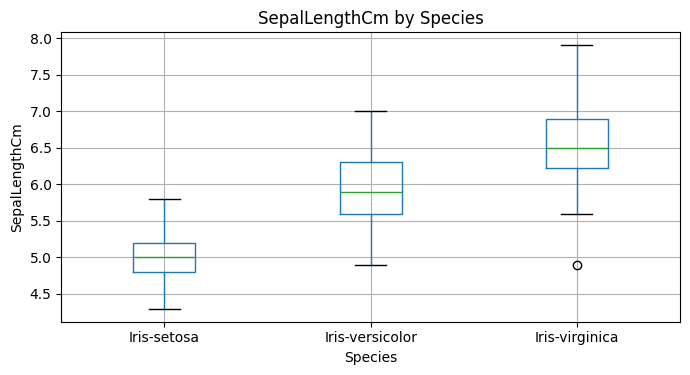

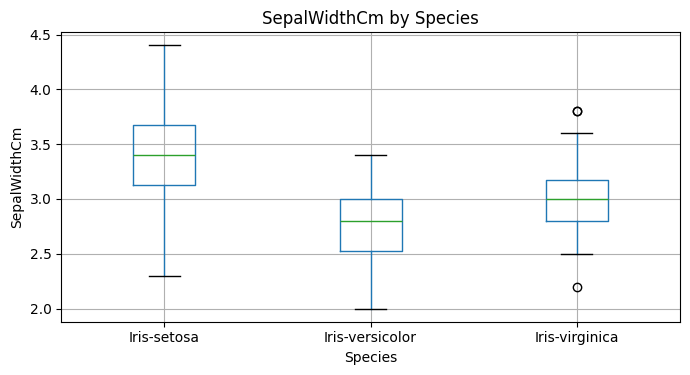

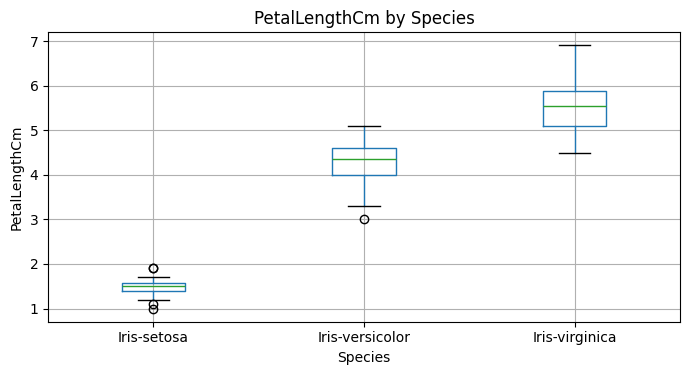

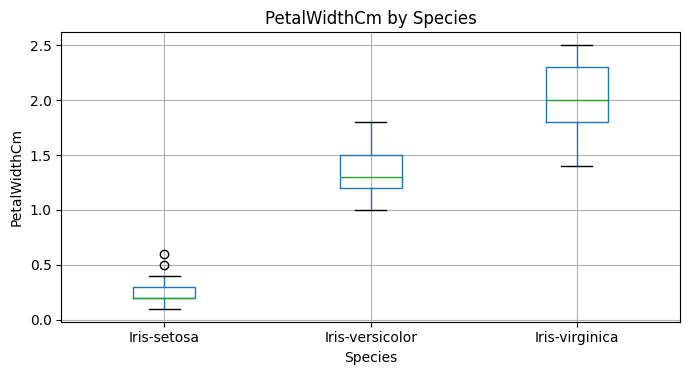

In [7]:
for col in numeric_cols:
    df.boxplot(column=col, by='Class Label', figsize=(7, 4))
    plt.title(f'{col} by Species')
    plt.suptitle('')
    plt.xlabel('Species')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()